In [2]:
%load_ext autoreload
%autoreload 2

%gui qt

In [3]:
import os
import sys
import importlib
import cv2

gui_source_dir = os.path.expanduser("~/Documents/talmolab/repos/lucid_lite/gui_source")
josh_source_dir = os.path.expanduser("~/Documents/talmolab/repos/lucid_lite")

# add folders to Python's system path so it can find local imports
if gui_source_dir not in sys.path:
    sys.path.insert(0, gui_source_dir)
    sys.path.insert(0, josh_source_dir)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import numpy as np
import pandas as pd
import sleap_io as sio
from scipy.optimize import linear_sum_assignment

from PySide6.QtGui import QImage

from lucid_lite.gui_source import graph_window
from graph_window import GroupGraphWindow

from lucid_lite.gui_source import main
from lucid_lite.gui_source import colors
from lucid_lite.gui_source.pose_data import Identity  
from lucid_lite.gui_source.colors import next_palette_color     

from josh_source import epipolar
from lucid_lite.josh_source import geometry
from lucid_lite.josh_source import geometry_old
# from lucid_lite.josh_source import tracker_old
from lucid_lite.josh_source import tracker
import luc3d_tracker_helper as lt

In [4]:
app, window = main.main(
    [
        "main.py",                                                          
        "/Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small"
    ]
)
# define globals
session = window.session

SKEL = session.skeleton
TRACK_COLOR_MAP = {track: colors.get_track_color(n) for n, track in enumerate(session.tracks)}
CAMERAS = {camera.name: camera for camera in session.cameras}

NODE_NAMES = [
    "Nose",
    "Ear_R",
    "Ear_L",
    "TTI",
    "TailTip",
    "Head",
    "Trunk",
    "Tail_0",
    "Tail_1",
    "Tail_2",
    "Shoulder_left",
    "Shoulder_right",
    "Haunch_left",
    "Haunch_right",
    "Neck"
]

def push_frame_assignments(
    window,
    frame_idx: int,
    palette: dict[int, tuple[str, str]] | None = None,   # identity_id -> (name, hex_color)
    node_weights: "np.ndarray | None" = None,             # default: ones(skeleton.nodes)
):
    """Compute groups at `frame_idx` and push them as the SOLE groupings.

    Calls josh_source.tracker.SingleFrameTrack._calc_edge_weights() then
    ._run_bfs(adjacency_matrix) to obtain the list of Group objects. Group
    index in that list becomes the identity_id. The viewer is seeked to
    frame_idx and switched to identity color mode.

    Returns (groups, assignments, adjacency_matrix, instance_list) for
    inspection from the notebook.
    """
    # import numpy as np
    # from pose_data import Identity
    # from colors import next_palette_color
    # >>> TRACKER API CALL site — flagged so it's easy to find when the
    #     tracker class layout changes. <<<
    from josh_source import tracker

    session = window.session

    # 0a. Frame must exist.
    fg = session.frame_group(frame_idx)
    if fg is None:
        raise ValueError(
            f"frame {frame_idx} not in session "
            f"(range {session.min_frame}..{session.max_frame})"
        )

    # 0b. Default node_weights = ones over the project skeleton.
    if node_weights is None:
        node_weights = {
            'Nose':   1,
            'Ear_R':  1,
            'Ear_L':  1,
            'TTI':    1,
            'TailTip':1,
            'Head':   1,
            'Trunk':  1,
            'Tail_0': 1,
            'Tail_1': 1,
            'Tail_2': 1,
            'Shoulder_left':  1,
            'Shoulder_right': 1,
            'Haunch_left':    1,
            'Haunch_right':   1,
            'Neck': 1,
        }

    # 0c. Persistent ProjCache across calls within the same kernel session
    #     so we don't recompute fundamental matrices every push.
    if not hasattr(push_frame_assignments, "_proj_cache"):
        # >>> TRACKER API CALL <<<
        push_frame_assignments._proj_cache = tracker.ProjCache()
    proj_cache = push_frame_assignments._proj_cache

    # 1. Run the tracker. _calc_edge_weights must run before _run_bfs —
    #    otherwise the adjacency matrix is all inf and BFS returns
    #    singleton groups only. The plan elides this but the notebook's
    #    earlier exploratory cell shows it's required.
    # >>> TRACKER API CALL <<<
    sft = tracker.SingleFrameTrack(
        fg, session.cameras, node_weights=node_weights, proj_cache=proj_cache
    )
    sft._calc_edge_weights()                # populates sft.adjacency_matrix
    groups = sft._run_bfs()  # tuple/list of Group objects

    # 2. Derive assignments: group index in returned list -> identity_id.
    assignments: dict[tuple[str, int], int] = {}
    for ident_id, g in enumerate(groups):
        # >>> TRACKER attribute access: Group.cam_track is list[(cam, track)]. <<<
        for cam, track in g.cam_track:
            assignments[(cam, track)] = ident_id

    # 3. Snapshot every visible (cam, track) at this frame so we know which
    #    instances need the -1 sentinel (didn't land in any group).
    visible_pairs: list[tuple[str, int]] = []
    for cam in session.camera_names():
        seen: set[int] = set()
        for inst in fg.get_instances(cam):
            if inst.track_idx is None or inst.track_idx in seen:
                continue
            seen.add(inst.track_idx)
            visible_pairs.append((cam, inst.track_idx))

    with session.batch_updates():
        # 4. Create any identity_id the tracker produced that doesn't exist.
        needed_ids = set(assignments.values())
        existing_ids = {i.id for i in session.identities}
        added = needed_ids - existing_ids
        for ident_id in sorted(added):
            if palette and ident_id in palette:
                name, color = palette[ident_id]
            else:
                name = f"id_{ident_id}"
                color = next_palette_color(len(session.identities))
            session.identities.append(Identity(id=ident_id, name=name, color=color))
            session._identity_counter = max(session._identity_counter, ident_id + 1)
        if added:
            session._emit("identities_changed")

        # 5. Reset prior per-frame overrides at this frame.
        prefix = f"{frame_idx}:"
        for key in [k for k in session.frame_identity_map if k.startswith(prefix)]:
            del session.frame_identity_map[key]

        # 6. -1 sentinel for visible pairs not covered by any group.
        assigned = set(assignments.keys())
        for (cam, track) in visible_pairs:
            if (cam, track) not in assigned:
                session.frame_identity_map[f"{frame_idx}:{cam}:{track}"] = -1

        # 7. Write the tracker-derived assignments verbatim.
        for (cam, track), ident_id in assignments.items():
            session.frame_identity_map[f"{frame_idx}:{cam}:{track}"] = ident_id

        session._emit("identity_map_changed")

        # 8. Store the full bundle so graph_window can draw edges from the
        #    matrix and label them with weights. >>> TRACKER attribute reads:
        #    sft.adjacency_matrix, sft.instance_list. <<<
        session.set_groups_for_frame(
            frame_idx,
            groups,
            adjacency_matrix=sft.adjacency_matrix,
            instance_list=sft.instance_list,
        )

        # 9. Identity-mode coloring.
        session.set_color_mode("identity")

    # 10. Seek outside batch_updates so decode + repaint happen cleanly.
    window.set_current_frame(frame_idx)

    return groups, assignments, sft.adjacency_matrix, sft.instance_list, sft



objc[89967]: Class AVFFrameReceiver is implemented in both /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1156f43a8) and /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x130cc43a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[89967]: Class AVFAudioReceiver is implemented in both /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1156f43f8) and /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x130cc43f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Error reconstructing FrameGroup: {'frame_idx': 0, 'instance_groups': [{'identity_idx': 2, 'points': [[48.274210531915045, -32.83364109623553, 1151.7922172896963], [83.07571957116458, -20.36973935475563, 1122.5767561306118], [48.60493063151847, -9.609941024846487, 1114.0203336967766], [118.1938555894995, 62.41805188430688, 1127.1038565057063], None, [63.183150565422935, -19.64047653555298, 1119.002217769748], [87.95001857752469, 28.003282991643157, 1113.8276833747993], [130.5468355849119, 98.39776894094688, 1127.8148572723746], [134.4872571635714, 120.10234736402975, 1114.5880371853975], [123.79095702963008, 147.5698802676192, 1119.798072697085], [45.2962926550307, -1.5282608506390873, 1138.1616990219975], [77.91839844248832, -15.904808598982878, 1147.9461334695127], [78.08237333977365, 56.15708812863012, 1134.041451388676], [110.51038828679032, 21.380386282260435, 1140.5983908960961], [66.71531746227073, -10.19857028548516, 1115.945911835526]], 'instances': {'0': {'Nose': [893.38220214

In [ ]:
'''
tracker flaws:

1. everything depends on the first and second 'pivot' frames, which
    are determined by the number of instances in the view, nothing
    about the quality of the views
2. if there is a singleton group from the first two frames, then
    they remain as a singleton group
3. order-dependent recruitment: the ordering of the cameras that are
    seen after the first 2 views also matters in terms of adding to the group
        eg. cam3 then cam4 is seen, cam4's addition to the same group
        can be influenced by cam3's additions
    - subpoint: NO ALGORITHM TO DETERMINE THE ORDER OF CAMERAS
4. why do hungarian on negative of score matrix???
5. reproj error: not using the distored points

'''

# Old Tracker

In [ ]:
importlib.reload(tracker_old)


curr_frame = window._current_frame
fg = session.frame_group(curr_frame)
cam_instances, cam_map, active_cams = tracker_old.get_instances(fg, session.cameras)

In [8]:
# from scipy.optimize import linear_sum_assignment
importlib.reload(geometry_old)
importlib.reload(tracker_old)

inst1 = cam_instances['back'][1]
inst2 = cam_instances['midL'][1]
cache=tracker_old.TrackerCache()
# # geometry.calc_epipolar_score(
# #     inst1, cam_map['back'],
# #     inst2, cam_map['midL'],
# #     cache
# # )

error = geometry_old.calc_reprojection_score(
    inst1, cam_map['back'],
    inst2, cam_map['midL'],
    cache
)
error

# test triangulation and reprojection
# gp = {'back': inst1, 'midL': inst2}
# X = geometry.triangulate_group(gp, cam_map, cache)
# reprojs = geometry.reproject_points(X, cache.getP(cam_map['back']))
# reproj_error = geometry.instance_pixel_distance(reprojs, inst1)
fg = session.frame_group(67)
pairs = tracker_old.match_pairwise(fg, session, cache, num_animals=4)
pairs
#

INFO:root:cam1: backL, cam2: midL


[{'backL': Instance(points=[(688.61572265625, 484.5345153808594), (636.6748657226562, 470.7451477050781), (662.8090209960938, 436.68377685546875), None, None, (656.6552734375, 458.6086730957031), (600.4605712890625, 400.542236328125), None, None, None, (660.548828125, 440.7054748535156), (626.4085083007812, 472.7599792480469), (628.6024169921875, 396.9112548828125), (588.7112426757812, 440.4897766113281), (642.828125, 448.51275634765625)], track_idx=0, type='predicted', score=0.9556068181991577),
  'midL': Instance(points=[(494.644775390625, 656.7603759765625), (544.8841552734375, 678.7184448242188), (506.7277526855469, 706.5262451171875), None, None, (520.9899291992188, 686.3880615234375), (560.6146240234375, 768.4002685546875), None, None, None, (507.0426025390625, 716.6810913085938), (554.7294921875, 694.4263305664062), (528.5979614257812, 782.6134033203125), (590.88427734375, 750.6467895507812), (532.7678833007812, 704.651123046875)], track_idx=0, type='predicted', score=0.93367421

In [ ]:

import importlib; importlib.reload(lt)
# lt.triangulate_group(gp, cam_map, caches=lt.TrackerCaches())[0]
cam_instances, cam_map, active_cams = lt.collect_instances(fg, session.cameras)
# cost3 = lt.match_pairwise(cam_instances, cam_map, active_cams, num_animals=4, prev_assignments=None, caches=lt.TrackerCaches())
groups = lt.match_pairwise(fg, session, caches=lt.TrackerCaches(), num_animals=4)
groups

In [23]:
results = lt.match_frame_instances(fg, session.cameras, session, caches=lt.TrackerCaches(), num_animals=4)
results['groups']
results['num_identities']
results['assignments']
results['targets3d'][0]



{'points3d': [array([  45.98249424,  -29.27086891, 1167.34859526]),
  array([ 3.34814615e-01, -4.47504862e+01,  1.15587883e+03]),
  array([  24.18922965,  -72.03577921, 1160.08240192]),
  array([ -46.58702995, -117.76207823, 1212.32401048]),
  array([-142.66722279,   16.56764548, 1201.73886826]),
  array([  17.97995723,  -53.32675225, 1158.39267635]),
  array([ -26.77470922, -107.01311231, 1166.57181135]),
  None,
  None,
  None,
  array([  24.42232077,  -71.50424953, 1189.06565649]),
  array([  -7.99694501,  -41.60166581, 1184.40709408]),
  array([  -7.77781823, -118.69065268, 1203.33057641]),
  array([ -44.10837824,  -75.41477364, 1198.28401833]),
  array([   6.63303986,  -63.60846938, 1161.17581981])],
 'groupIdx': 0,
 'prevInstances': {'backL': Instance(points=[(688.61572265625, 484.5345153808594), (636.6748657226562, 470.7451477050781), (662.8090209960938, 436.68377685546875), None, None, (656.6552734375, 458.6086730957031), (600.4605712890625, 400.542236328125), None, None, None,

# New Stuff

In [6]:
node_weights = {
    'Nose':   0.7,
    'Ear_R':  0.7,
    'Ear_L':  0.7,
    'TTI':    1,
    'TailTip':0,
    'Head':   1,
    'Trunk':  0.8,
    'Tail_0': 0,
    'Tail_1': 0,
    'Tail_2': 0,
    'Shoulder_left':  0.7,
    'Shoulder_right': 0.7,
    'Haunch_left':    0.7,
    'Haunch_right':   0.7,
    'Neck': 0.7
}

(array([[ 1.82388612, 17.58779591, 12.86659953, 43.2149595 ],
       [20.70189956,  1.91725823, 14.55978084, 56.4027267 ],
       [41.74380032, 47.58088777, 48.48404977,  4.0132849 ]]), ('backL', 'topL'))


np.float64(48.48404977215799)

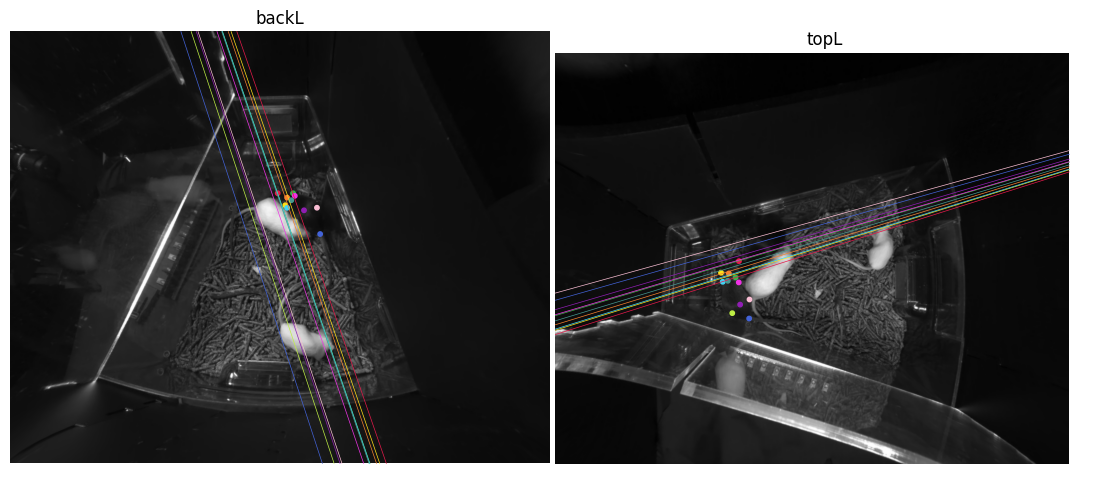

In [ ]:
importlib.reload(geometry)
importlib.reload(tracker)

fg = session.frame_group(89)
projcache = tracker.ProjCache()
sft = tracker.SingleFrameTrack(fg, session.cameras, node_weights=node_weights, proj_cache=projcache)
edges = sft._calc_edge_weights()
groups = sft._run_bfs()


print(sft.get_edges('backL', 'topL'))
err = sft.visualize_epipolar_pair(
    window=window,
    cam1_name='backL',
    cam2_name='topL',
    track_idx=(2, 3),
)
err

In [29]:
for g in groups:
    print(np.mean(list(g.reproj_score.values())))

10.069466351687153
5.202649536450599
12.099920872431188
8.728848980329516


In [39]:
for g in groups:
    print(np.mean(list(g.reproj_score.values())))

10.069466351687153
5.518077071257907
14.00078737538214
8.937522562043315


In [182]:
print(sft.get_edges('back', 'midL'))
# sft.camera_pairs

(array([[  2.13797537, 169.04068569,  61.15508306],
       [173.39961305,   1.07751744, 222.31947708],
       [ 72.84441362, 238.61097624,  39.0623155 ],
       [ 58.66111967, 222.10511504,   1.96258595]]), ('back', 'midL'))


In [126]:
pts = sft.instance_by_cam['back'][0][1]
K = np.array(sft.cam_map['back'].matrix)
np.linalg.norm(pts - cv2.undistortPoints(pts, K, np.array(sft.cam_map['back'].dist), P=K).squeeze(1), axis=1)

array([24.98994306, 22.46707944, 33.845896  ,         nan,         nan,
       26.8209434 , 41.56836816,         nan,         nan,         nan,
       39.11971738, 24.36981986])

In [168]:
np.mean(list(groups[0].reproj_score.values()))

np.float64(9.986261449848419)

In [75]:
my_assignments = {}

for i, g in enumerate(groups):
     for match in g.cam_track:
          my_assignments[match] = i

my_assignments

palette = {
    0: ('id_0', '#ff3300'),
    1: ('id_1', '#3366ff'),
    2: ('id_2', '#00ff00'),
    3: ('id_3', '#cc00cc'),
}

In [8]:
FRAME_IDX = 89

In [ ]:
importlib.reload(graph_window)


palette = {
    0: ("id_0", "#e41a1c"),
    1: ("id_1", "#377eb8"),
    2: ("id_2", "#4daf4a"),
    3: ("id_3", "#984ea3"),
}

groups, assignments, adj, inst_list, sft = push_frame_assignments(
    window, FRAME_IDX, palette=palette, node_weights=node_weights
)

# ---- immediate verification -------------------------------------------------
print(f"groups @ {FRAME_IDX}:")
for i, g in enumerate(groups):
    print(f"  group[{i}] valid={getattr(g, 'valid', '?')} cam_track={g.cam_track}")

print()
print(f"adjacency_matrix : shape={adj.shape}, "
      f"finite edges={int(np.isfinite(adj).sum() // 2)}")  # /2 for upper triangle symmetry
print(f"instance_list    : {len(inst_list)} entries")
print()
print("identities       :", [(i.id, i.name, i.color) for i in session.identities])
print("color_mode       :", session.color_mode)
print("current_frame    :", window._current_frame)
print("stored bundle?   :", FRAME_IDX in session.frame_tracker_groups)
print("map@FRAME_IDX    :", {k: v for k, v in session.frame_identity_map.items()
                             if k.startswith(f"{FRAME_IDX}:")})

# Per-instance resolution at this frame — what the overlay will paint.
fg = session.frame_group(FRAME_IDX)
print()
print("overlay resolution:")
for cam in session.camera_names():
    for inst in fg.get_instances(cam):
        rid = session.get_identity_id_for_track(FRAME_IDX, cam, inst.track_idx)
        ident = session.get_identity(rid)
        print(f"  {cam:>6} t{inst.track_idx} -> id={rid} ident={ident}")

gw = GroupGraphWindow(session, FRAME_IDX, parent=window)
gw.show()

groups @ 89:
  group[0] valid=True cam_track=[('back', 0), ('backL', 0), ('mid', 0), ('midL', 0), ('top', 0), ('topL', 0)]
  group[1] valid=True cam_track=[('back', 1), ('backL', 1), ('mid', 1), ('midL', 1), ('top', 1), ('topL', 1)]
  group[2] valid=True cam_track=[('back', 2), ('top', 2), ('topL', 2)]
  group[3] valid=True cam_track=[('back', 3), ('backL', 3), ('midL', 3), ('topL', 3)]

adjacency_matrix : shape=(19, 19), finite edges=39
instance_list    : 19 entries

identities       : [(0, 'id_0', '#e41a1c'), (1, 'id_1', '#377eb8'), (2, 'id_2', '#4daf4a'), (3, 'id_3', '#984ea3')]
color_mode       : identity
current_frame    : 89
stored bundle?   : True
map@FRAME_IDX    : {'89:back:0': 0, '89:backL:0': 0, '89:mid:0': 0, '89:midL:0': 0, '89:top:0': 0, '89:topL:0': 0, '89:back:1': 1, '89:backL:1': 1, '89:mid:1': 1, '89:midL:1': 1, '89:top:1': 1, '89:topL:1': 1, '89:back:2': 2, '89:top:2': 2, '89:topL:2': 2, '89:back:3': 3, '89:backL:3': 3, '89:midL:3': 3, '89:topL:3': 3}

overlay resolu

Error calling Python override of QWidget::paintEvent(): Traceback (most recent call last):
  File "/Users/joshuapark/Documents/talmolab/repos/lucid_lite/gui_source/video_panel.py", line 9, in paintEvent
    from PySide6.QtWidgets import QPushButton, QWidget
                            ^^^^^^^^^^
AttributeError: 'VideoPanelWidget' object has no attribute '_zoom'
Error calling Python override of QWidget::paintEvent(): Traceback (most recent call last):
  File "/Users/joshuapark/Documents/talmolab/repos/lucid_lite/gui_source/video_panel.py", line 9, in paintEvent
    from PySide6.QtWidgets import QPushButton, QWidget
                            ^^^^^^^^^^
AttributeError: 'VideoPanelWidget' object has no attribute '_zoom'
Error calling Python override of QWidget::paintEvent(): Traceback (most recent call last):
  File "/Users/joshuapark/Documents/talmolab/repos/lucid_lite/gui_source/video_panel.py", line 9, in paintEvent
    from PySide6.QtWidgets import QPushButton, QWidget
              

: 

In [34]:
groups[2].valid
sft.fg.frame_idx

89

(array([[  2.73427812, 217.66882833,  96.89472967,  70.12195443],
       [220.37893063,   1.17855585, 320.75421397, 250.08666462],
       [ 99.38539853, 316.02012393,   3.11757518,  56.39807959],
       [ 71.43371377, 246.37263433,  61.50643213,   2.83252058]]), ('back', 'topL'))


np.float64(3.117575180048161)

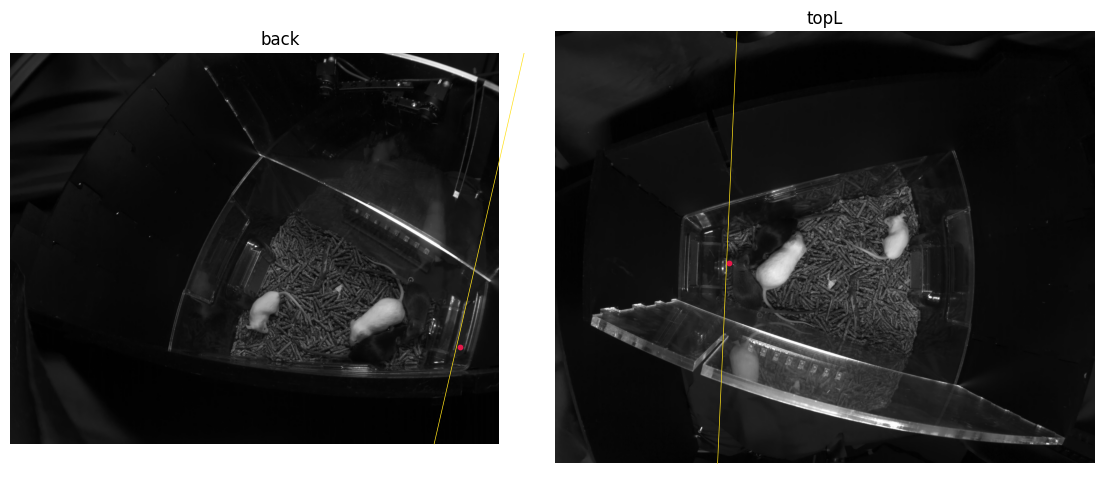

In [36]:
print(sft.get_edges('back', 'topL'))
err = sft.visualize_epipolar_pair(
    window=window,
    cam1_name='back',
    cam2_name='topL',
    track_idx=(2, 2),
)
err

In [46]:
print(sft.instance_by_cam['back'][2][-1])
print(sft.fg.instances['back'][2].points)

[[1092.40000532  797.83692226]
 [1115.04740166  733.46500754]
 [1179.40295361  771.15419396]
 [1086.96678498  613.63373523]
 [1142.44823918  759.63032366]
 [1125.50823676  650.60302137]
 [1171.29127466  751.36497235]
 [1104.12519673  724.69781085]
 [          nan           nan]
 [1079.44580067  665.845213  ]
 [1151.0599301   738.33331256]]
[(1028.3726806640625, 757.35693359375), (1050.533935546875, 703.3529052734375), (1084.326904296875, 725.4295043945312), (1040.482177734375, 603.023681640625), (930.3677978515625, 531.4385986328125), (1064.6370849609375, 721.2420654296875), (1064.3006591796875, 633.08447265625), None, (988.4840087890625, 559.4240112304688), (958.5677490234375, 549.4268798828125), (1082.3846435546875, 711.2635498046875), (1044.2955322265625, 697.244384765625), None, (1032.28857421875, 649.3011474609375), (1072.258544921875, 703.3916015625)]
